In [21]:
# Importar a biblioteca pandas para manipulação de dados
import pandas as pd

# Carregar o ficheiro de atividade diária
# (Certifique-se de que o ficheiro dailyActivity_merged.csv está na mesma pasta que o seu notebook)
daily_activity = pd.read_csv('dailyActivity_merged.csv')

# Visualizar as primeiras 5 linhas para confirmar que os dados foram carregados corretamente
daily_activity.head()
print("--- INFORMAÇÕES DA TABELA ---")
daily_activity.info()

print("\n--- ESTATÍSTICAS DE RESUMO ---")
display(daily_activity.describe())

numero_utilizadores = daily_activity['Id'].nunique()
print(f"\nNúmero de utilizadores únicos: {numero_utilizadores}")

duplicados = daily_activity.duplicated().sum()
print(f"Número de linhas duplicadas: {duplicados}")

daily_activity['ActivityDate'] = pd.to_datetime(daily_activity['ActivityDate'])

daily_activity['Dia_da_Semana'] = daily_activity['ActivityDate'].dt.day_name()

daily_activity.head()

--- INFORMAÇÕES DA TABELA ---
<class 'pandas.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        457 non-null    int64  
 1   ActivityDate              457 non-null    str    
 2   TotalSteps                457 non-null    int64  
 3   TotalDistance             457 non-null    float64
 4   TrackerDistance           457 non-null    float64
 5   LoggedActivitiesDistance  457 non-null    float64
 6   VeryActiveDistance        457 non-null    float64
 7   ModeratelyActiveDistance  457 non-null    float64
 8   LightActiveDistance       457 non-null    float64
 9   SedentaryActiveDistance   457 non-null    float64
 10  VeryActiveMinutes         457 non-null    int64  
 11  FairlyActiveMinutes       457 non-null    int64  
 12  LightlyActiveMinutes      457 non-null    int64  
 13  SedentaryMinutes          457 non-null    int6

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,4.570000e+02,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000
mean,4.628595e+09,6546.562363,4.663523,4.609847,0.179427,1.180897,0.478643,2.890197,0.001904,16.623632,13.070022,170.070022,995.282276,2189.452954
std,2.293781e+09,5398.493064,4.082072,4.068540,0.849232,2.487159,0.830995,2.237523,0.008487,28.919704,36.208635,122.205372,337.021404,815.484523
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,32.000000,0.000000
25%,2.347168e+09,1988.000000,1.410000,1.280000,0.000000,0.000000,0.000000,0.870000,0.000000,0.000000,0.000000,64.000000,728.000000,1776.000000
50%,4.057193e+09,5986.000000,4.090000,4.090000,0.000000,0.000000,0.020000,2.930000,0.000000,0.000000,1.000000,181.000000,1057.000000,2062.000000
75%,6.391747e+09,10198.000000,7.160000,7.110000,0.000000,1.310000,0.670000,4.460000,0.000000,25.000000,16.000000,257.000000,1285.000000,2667.000000
max,8.877689e+09,28497.000000,27.530001,27.530001,6.727057,21.920000,6.400000,12.510000,0.100000,202.000000,660.000000,720.000000,1440.000000,4562.000000



Número de utilizadores únicos: 35
Número de linhas duplicadas: 0


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Dia_da_Semana
0,1503960366,2016-03-25,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819,Friday
1,1503960366,2016-03-26,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154,Saturday
2,1503960366,2016-03-27,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944,Sunday
3,1503960366,2016-03-28,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932,Monday
4,1503960366,2016-03-29,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886,Tuesday


In [22]:
medias_por_dia = daily_activity.groupby('Dia_da_Semana')[['TotalSteps', 'Calories']].mean().reset_index()

ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
medias_por_dia['Dia_da_Semana'] = pd.Categorical(medias_por_dia['Dia_da_Semana'], categories=ordem_dias, ordered=True)
medias_por_dia = medias_por_dia.sort_values('Dia_da_Semana')

display(medias_por_dia)

,Dia_da_Semana,TotalSteps,Calories
1,Monday,7118.588235,2252.867647
5,Tuesday,4914.917808,1742.424658
6,Wednesday,7510.708333,2377.458333
4,Thursday,6847.083333,2297.812500
0,Friday,6737.561644,2313.547945
2,Saturday,7089.773333,2277.586667
3,Sunday,6058.013889,2167.597222


In [23]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


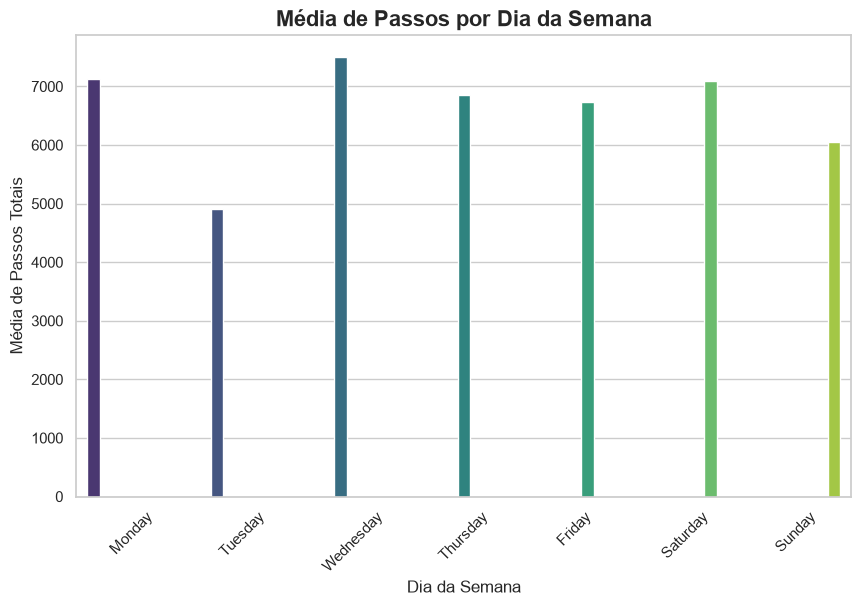

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.barplot(data=medias_por_dia, x='Dia_da_Semana', y='TotalSteps', palette='viridis', hue='Dia_da_Semana', legend=False)

plt.title('Média de Passos por Dia da Semana', fontsize=16, fontweight='bold')
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Média de Passos Totais', fontsize=12)
plt.xticks(rotation=45) 

plt.show()